In [1]:
import requests
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
import networkx as nx

In [2]:
# Run this cell first, then restart the runtime before continuing
!pip3 install --upgrade git+https://github.com/tantantan12/itom6219.git
!pip3 install pingouin

  Cloning https://github.com/tantantan12/itom6219.git to /tmp/pip-req-build-o2crae_q
  Running command git clone --filter=blob:none --quiet https://github.com/tantantan12/itom6219.git /tmp/pip-req-build-o2crae_q
  Resolved https://github.com/tantantan12/itom6219.git to commit c2ba75c8a6d468dc3040f71c1b2c78c2fe953bc6
  Preparing metadata (setup.py) ... done
  Created wheel for itom6219: filename=itom6219-0.1-py3-none-any.whl size=3748 sha256=759480c14e8a8cf8959814179b418354bebc6b189b5f1288e7e3821173fd583e
  Stored in directory: /tmp/pip-ephem-wheel-cache-19hn0714/wheels/2c/9b/ba/c9854aaa38edfa4413050897190adfff0cfda190a70d818904
Successfully built itom6219
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 640.2 kB/s eta 0:00:00


# Project 1: Nike

On Facebook, business pages can "like" other pages, and a directed network could be derived from this liking relationship. Jane collected all the pages liked by Nike and the linking relationships among these pages. This results in two datesets:
- facebook_node_attributes.csv
- facebook_data.csv

The first dataset includes page attributes and the second data contains the edgelist information. We will visualize and explore how centrality attributes, together with other node-level attributes, could be used for spokeperson selection.




## Problem 1.1
Generate a subgraph with nodes that have more than 80,000,000 fan count. Visualize this network with node labels and upload the network graph. Make sure to use kamada_kawai_layout as the layout algorithm.

Tips: You can visualize the whole network first and then generate the subgragh.

Expected output:
- code
- gragh

> 💡 **Hint:** See class notebook **Section 1.3** for building a graph from an edgelist, **Section 1.4** for visualization parameters (including layout algorithms), and **Section 1.6** for filtering nodes by attribute and creating a subgraph.

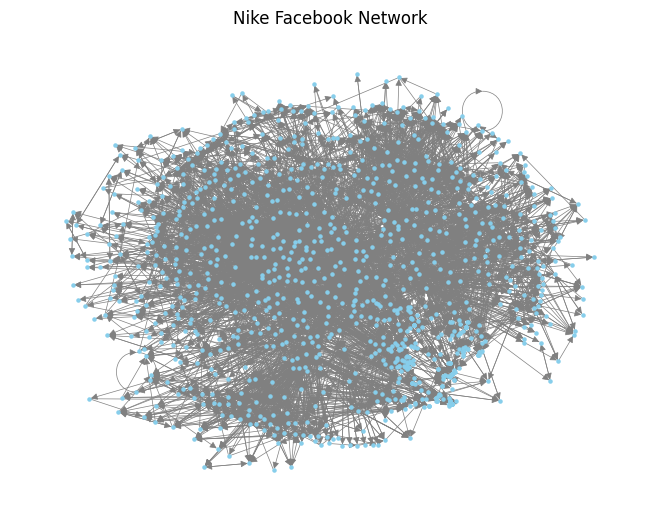

In [ ]:
edgelist=pd.read_csv('facebook_data.csv')
G=nx.from_pandas_edgelist(
# complete the code
edgelist,
    source='username1',
    target='username2',
    create_using=nx.DiGraph()
) # No need to add create_using=nx.DiGraph() if it is an undirected graph

nx.draw(G, with_labels=False, node_size=5,node_color='skyblue',width=0.5, edge_color='gray',pos= nx.kamada_kawai_layout(G))
plt.title('Nike Facebook Network')
plt.show()


In [ ]:
# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
# Calculate in-degree centrality
in_degree_centrality = nx.in_degree_centrality(G)
# Calculate out-degree centrality
out_degree_centrality = nx.out_degree_centrality(G)
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Save node attributes.
nx.set_node_attributes(G, eigenvector_centrality, 'eigenvector_centrality')
nx.set_node_attributes(G, in_degree_centrality, 'in_degree_centrality')
nx.set_node_attributes(G, out_degree_centrality, 'out_degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')


In [ ]:
node_attribute=pd.read_csv('facebook_node_attributes.csv')

for index, row in node_attribute.iterrows():
    node_id = row['username']
    attributes = row.drop(['username']).to_dict()
    nx.set_node_attributes(G, {node_id: attributes})
    ## Complete the code to add external node attributes to the network

In [ ]:
attributes_list=[]
for node, attributes in G.nodes(data=True):
    attributes_list.append(attributes)

attributes_df=pd.DataFrame(attributes_list)


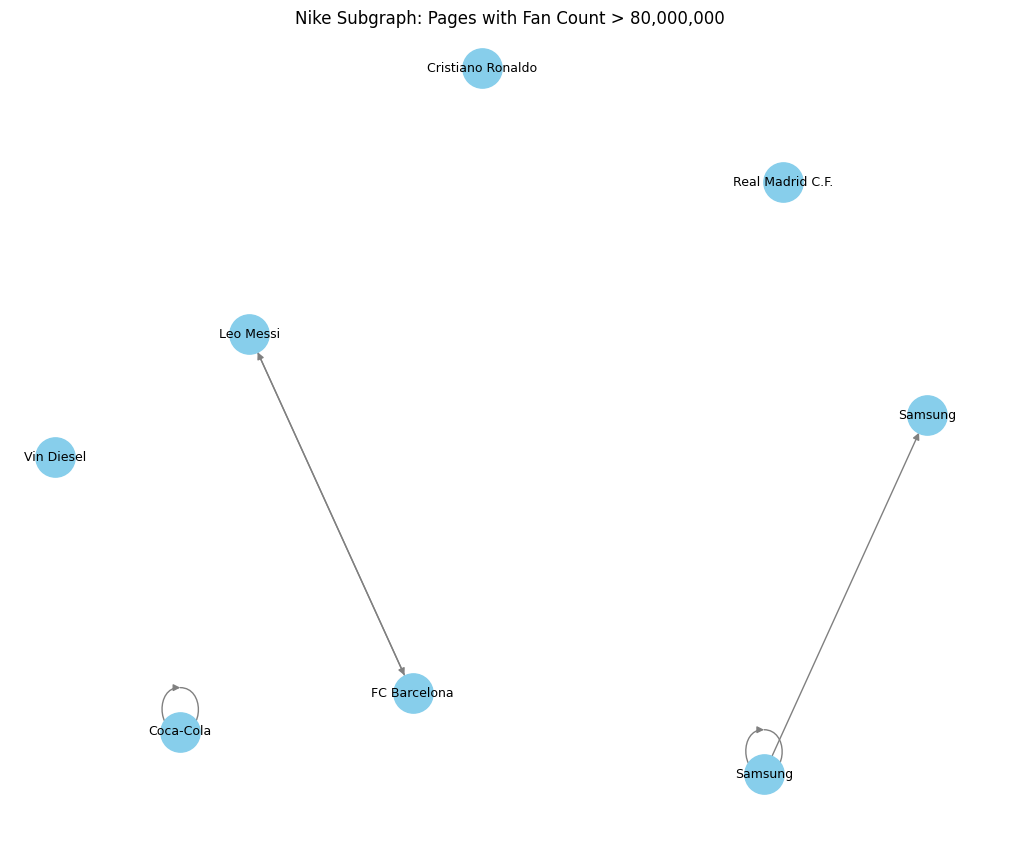

In [ ]:
selected_nodes = []
for node, data in G.nodes(data=True):
    if data.get('fan_count', 0) > 80_000_000:
        selected_nodes.append(node)

subgraph = G.subgraph(selected_nodes).copy()

plt.figure(figsize=(10, 8))
nx.draw(
    subgraph,
    with_labels=True,
    node_size=800,
    node_color='skyblue',
    width=1.0,
    edge_color='gray',
    font_size=9,
    pos=nx.kamada_kawai_layout(subgraph),
    labels={node: subgraph.nodes[node].get('label', node) for node in subgraph.nodes()}
)

plt.title('Nike Subgraph: Pages with Fan Count > 80,000,000')
plt.savefig("problem1_1.png", bbox_inches="tight")
plt.show()

### Your Output — Problem 1.1



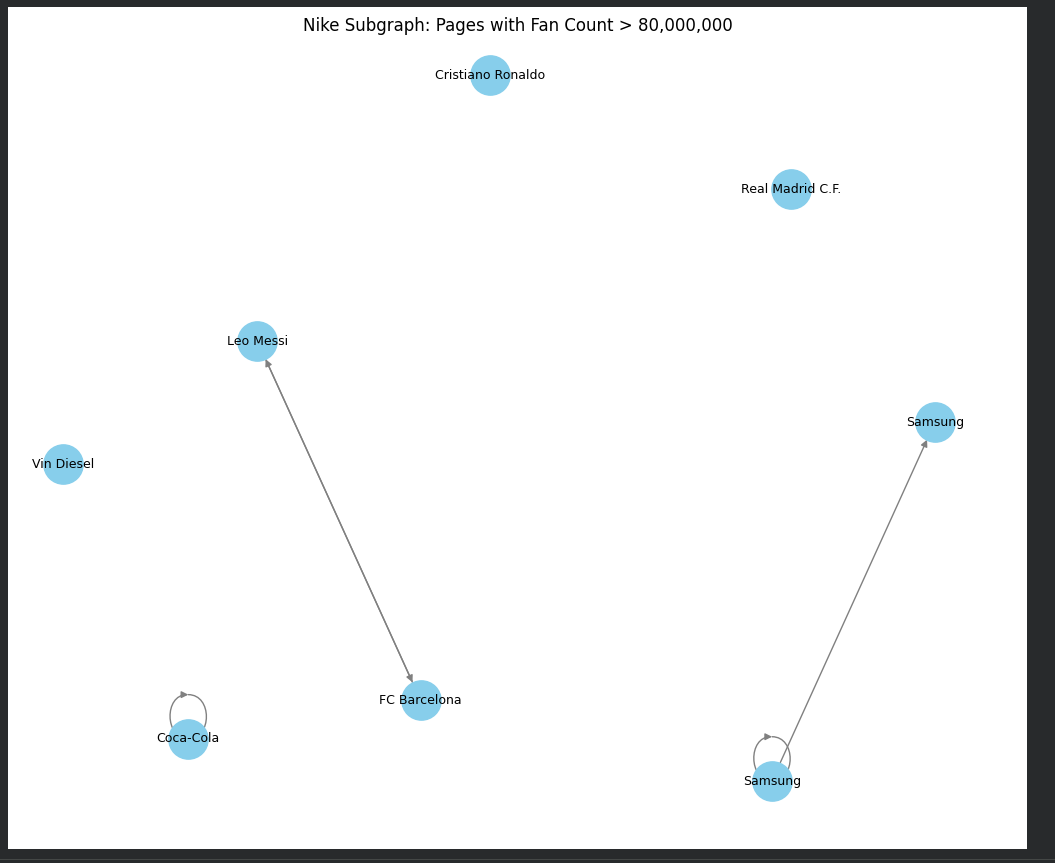

---
> 📤 **Submit to Canvas — Problem 1.1:** Upload the subgraph network visualization.
---

## Problem 1.2
For this subgraph, generate a dataframe to save all attributes of the nodes. Copy the code here. Then, using network centrality measures as support to discuss who Nike should hire as spokesperson if Nike focuses not only on fan count but also network centrality.

Tip: use sort_values(by= "columname", ascending=False) to identify nodes with high centrality measures.

Expected output:
- Code
- Propose 3 spokespeople for Nike. For each spokesperson, discuss their centrality and why you proposed them. Demonstrate your knowledge about different centrality measures in the discussion.

> 💡 **Hint:** See class notebook **Section 1.5** for definitions and calculation of centrality measures, and **Section 1.6** for saving node attributes into a dataframe.

In [ ]:
attributes_list = []
for node, attributes in subgraph.nodes(data=True):
    row = {'username': node}
    row.update(attributes)
    attributes_list.append(row)

attributes_df = pd.DataFrame(attributes_list)
attributes_df = attributes_df.sort_values(
    by=['eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality'],
    ascending=False
)
attributes_df


,username,eigenvector_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,closeness_centrality,Unnamed: 0,name,label,category,post_activity,fan_count,talking_about_count,users_can_post
2,Cristiano,0.063196,0.038160,0.025440,0.033012,0.253648,10,8.122120e+10,Cristiano Ronaldo,Athlete,0.03,122672469,688102,no
6,fcbarcelona,0.058345,0.027397,0.008806,0.008449,0.231474,748,1.970000e+11,FC Barcelona,Sports Team,0.21,102653035,924723,no
3,leomessi,0.055038,0.021526,0.002935,0.001552,0.230255,193,1.760000e+14,Leo Messi,Athlete,0.01,89957459,680636,no
5,Coca-Cola,0.045919,0.029354,0.002935,0.007554,0.238856,413,4.079631e+10,Coca-Cola,Food & Beverage,0.00,107873884,7025,yes
1,RealMadrid,0.024105,0.012720,0.002935,0.000804,0.208797,170,1.903472e+10,Real Madrid C.F.,Sports Team,0.09,109425487,904634,no
0,SamsungUS,0.015486,0.003914,0.004892,0.002450,0.205604,555,7.224957e+09,Samsung,Electronics Company,0.43,159997828,87893,yes
4,VinDiesel,0.006623,0.003914,0.000000,0.000000,0.185834,480,8.956227e+10,Vin Diesel,Artist,0.01,99132429,47288,no
7,SamsungUK,0.005604,0.003914,0.004892,0.000750,0.185787,234,1.270000e+14,Samsung,Computer Company,0.22,159992225,12253,yes


### Your Output — Problem 1.2

```
Within the high-fan-count subgraph, Cristiano Ronaldo is the strongest overall choice because he is not only one of the biggest pages by fan count, but also ranks highest on eigenvector centrality, in-degree centrality, out-degree centrality, betweenness centrality, and closeness centrality. That means he is connected to other influential pages, receives attention from many pages, points outward to many pages, acts as a bridge across the network, and can spread messages efficiently through the graph.

My second choice is Leo Messi. His fan count is still extremely large, but more importantly, his eigenvector centrality, in-degree centrality, and closeness centrality are all strong. This suggests that Messi is embedded in an influential part of the network and is well positioned to help Nike spread information quickly to other central pages. My third choice is FC Barcelona. Even though it is a team page rather than an individual, it has a very high fan count and strong eigenvector and betweenness centrality, which makes it valuable for reaching multiple parts of the network. In contrast, pages like Samsung have very large fan counts, but weaker centrality values, so they are less attractive if Nike wants both visibility and network influence.
```

---
> 📤 **Submit to Canvas — Problem 1.2:** Submit your spokesperson proposals with centrality-based justifications.
---

## Problem 1.3

For the whole network (no filtering), perform community detection and plot the network by allowing nodes in different communities to be colored differently. Please note that community detection is only applicable to undirected network, and you will need to use ```G = G.to_undirected()``` to turn the network to an undirected network before you perform community detection.

Expected output:
- Code.
- A network gragh to show communities (no labels are needed for nodes).

> 💡 **Hint:** See class notebook **Section 1.8** for community detection, mapping nodes to community IDs, and coloring nodes by community.

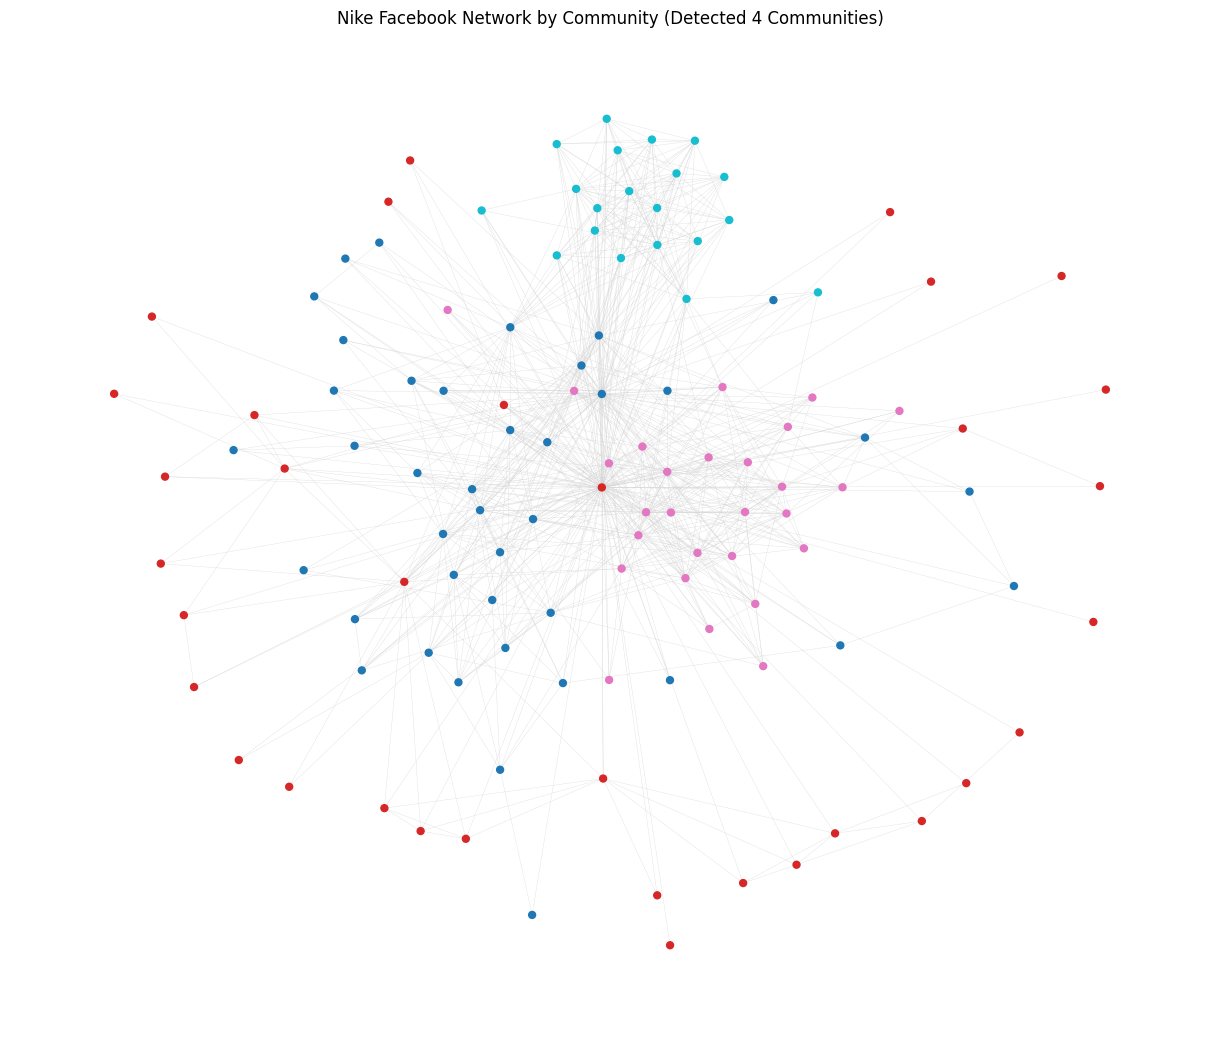

In [ ]:
G = G.to_undirected()

communities = greedy_modularity_communities(G)

node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i
        G.nodes[node]['community'] = i

colors = []
for n in G.nodes():
    colors.append(node_community[n])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    node_color=colors,
    with_labels=False,
    node_size=25,
    width=0.2,
    edge_color='lightgray',
    cmap=plt.cm.tab10
)
plt.title(f'Nike Facebook Network by Community (Detected {len(communities)} Communities)')
plt.savefig("problem1_3.png", bbox_inches="tight")
plt.show()


### Your Output — Problem 1.3



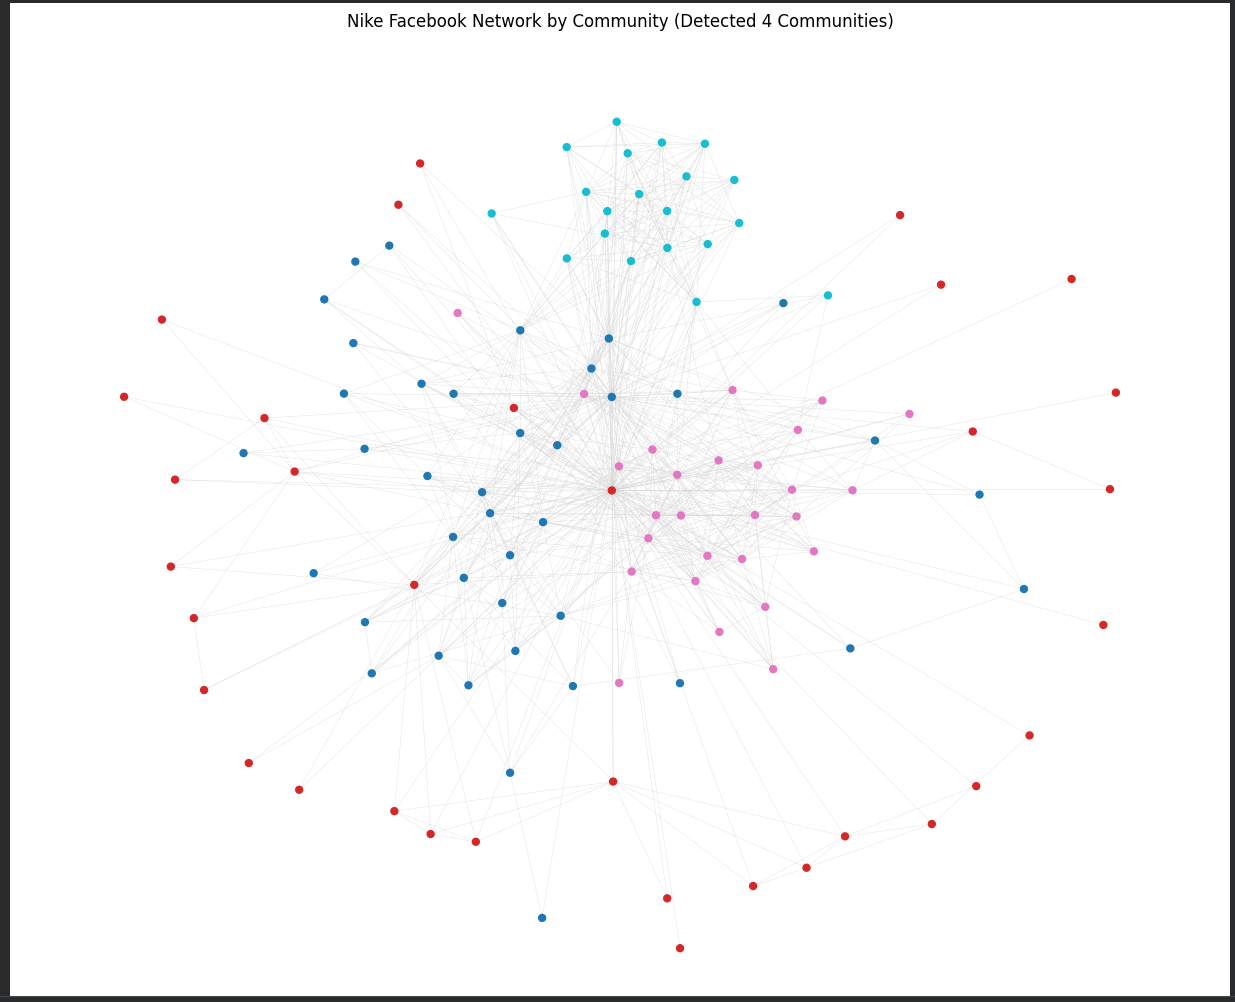
---
> 📤 **Submit to Canvas — Problem 1.3:** Upload the community-colored network graph.
---

# Project 2: Bright Kite
Brightkite was a location-based social networking website. Users were able to "check in" at places by using text messaging or one of the mobile applications and they were able to see who is nearby and who has been there before. The source of the data is [here](https://snap.stanford.edu/data/loc-brightkite.html).

## Problem 2.1
Generate a network using connections on BrightKite and display the network. Note that this is an undirected network and we need to remove ```create_using=nx.DiGraph()``` when generating this network. Upload your network graph below.

Expected Output:
- Code
- Network Plot

> 💡 **Hint:** See class notebook **Section 1.3** for building a graph from an edgelist and **Section 1.4** for visualization parameters.

In [ ]:
edgelist=pd.read_csv('brightkite_edgelist.csv')
edgelist

,node1,node2
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5
...,...,...
1575,121,61
1576,121,82
1577,121,88
1578,121,120


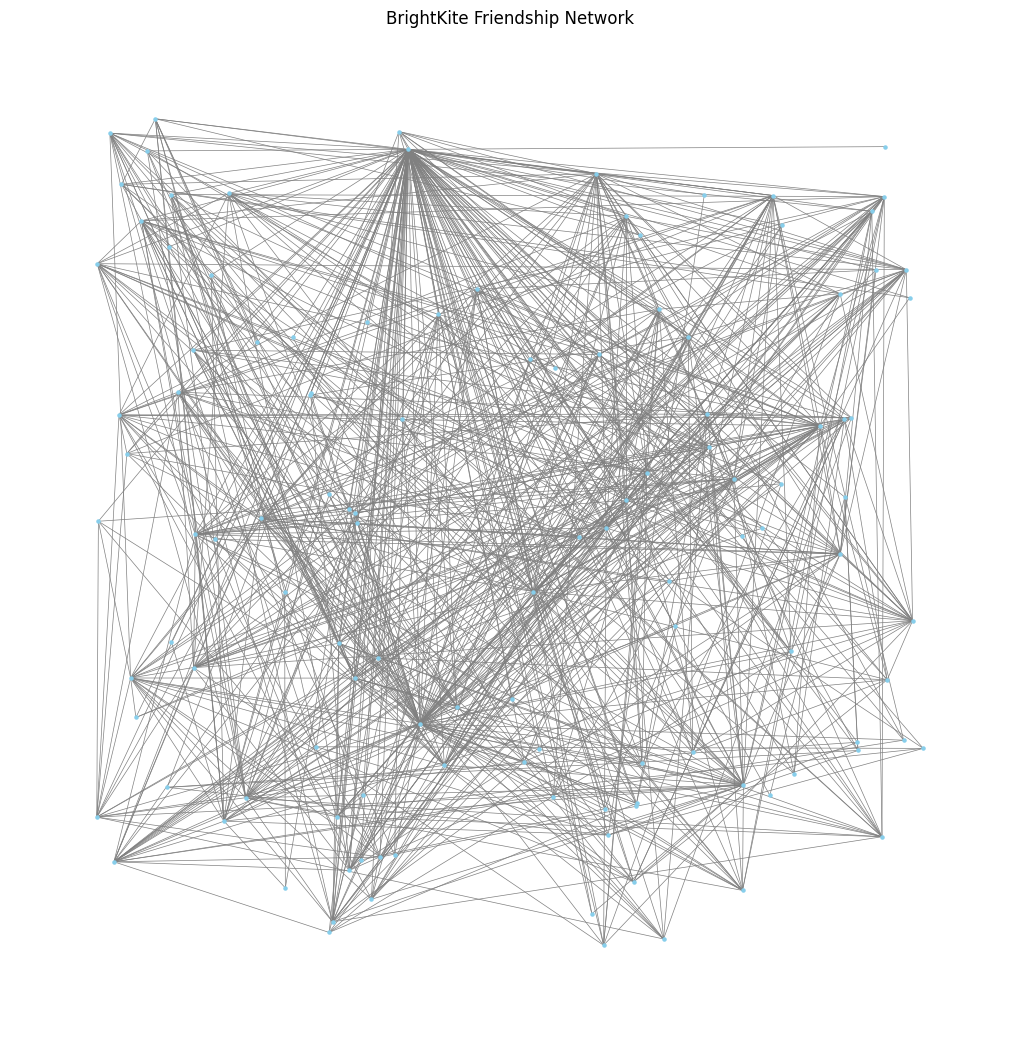

In [ ]:
G = nx.from_pandas_edgelist(
    edgelist,
    source='node1',
    target='node2'
)  # No need to add create_using=nx.DiGraph() if it is an undirected graph

plt.figure(figsize=(10, 10))
nx.draw(
    G,
    with_labels=False,
    node_size=5,
    node_color='skyblue',
    width=0.5,
    edge_color='gray',
    pos=nx.random_layout(G, seed=42)
)
plt.title('BrightKite Friendship Network')
plt.savefig("problem2_1.png", bbox_inches="tight")
plt.show()


### Your Output — Problem 2.1


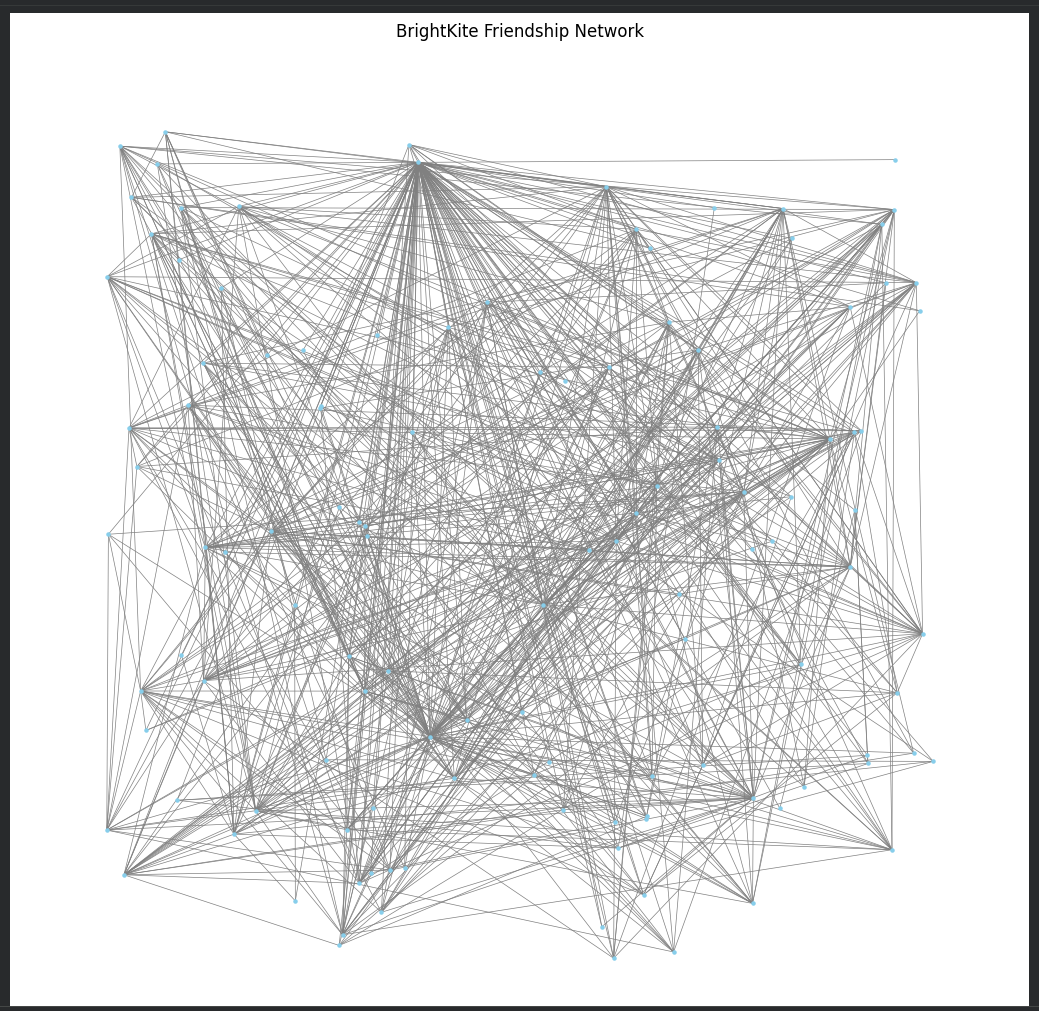

---
> 📤 **Submit to Canvas — Problem 2.1:** Upload the BrightKite network visualization.
---

## Problem 2.2
Generate centrality measures and add these network attributes to the network. Note that for undirected network, in-degree and out-degree are the same. We generate degree centrality by using ```degree_centrality = nx.degree_centrality(G)```.

Then, import brightkite_checkins.csv and add external attributes of "checkins" to the network as a new network attribute. We further include node name as an additional feature by using the following code:
```
for node in G.nodes():
    G.nodes[node]['name'] = node
```
Finally, save all node-level attributes into a dataframe and print this dataframe.

Expected output:
- Code
- Answer this question: how many nodes are there in this network?


> 💡 **Hint:** See class notebook **Section 1.5** for calculating centrality measures and adding them as node attributes, and **Section 2.2** for attaching external attributes from a dataframe to network nodes.

In [ ]:
# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Save node attributes.
nx.set_node_attributes(G, eigenvector_centrality, 'eigenvector_centrality')
nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')


Import the checkin data

In [ ]:
node_attribute=pd.read_csv("brightkite_checkins.csv")

for index, row in node_attribute.iterrows():
    node_id = int(row['node'])
    attributes = row.drop(['node']).to_dict()  # Convert row to dictionary excluding node_id
    nx.set_node_attributes(G, {node_id: attributes})

Save node attributes into a dataframe

In [ ]:
for node in G.nodes():
    G.nodes[node]['name'] = node

attributes_list = []
for node, attributes in G.nodes(data=True):
    row = {'node': node}
    row.update(attributes)
    attributes_list.append(row)

attributes_df = pd.DataFrame(attributes_list)
print(f"Number of nodes in this network: {G.number_of_nodes():,}")
attributes_df

Number of nodes in this network: 121


,node,community,eigenvector_centrality,degree_centrality,betweenness_centrality,closeness_centrality,checkins,name
0,0,1,0.365188,1.000000,0.610739,1.000000,2100,0
1,1,3,0.110019,0.166667,0.000833,0.545455,1210,1
2,2,1,0.084494,0.166667,0.007907,0.545455,2100,2
3,3,3,0.110094,0.158333,0.003335,0.542986,1807,3
4,4,3,0.089532,0.133333,0.000306,0.535714,779,4
...,...,...,...,...,...,...,...,...
116,118,0,0.040560,0.058333,0.000000,0.515021,43,118
117,119,1,0.017976,0.016667,0.000000,0.504202,2,119
118,120,0,0.031783,0.058333,0.000460,0.515021,7,120
119,121,0,0.046360,0.066667,0.000481,0.517241,4,121


### Your Output — Problem 2.2

```
+------------------------------------------------------------+
| How many nodes are there in this network? 121 Nodes
```

---
> 📤 **Submit to Canvas — Problem 2.2:** Submit your code and answer the node count question.
---

## Problem 2.3
The platform wants to install a recommendation system to recommend friends. Which users are likely to be friends? Perform an edge prediction based on Jaccard similarity coefficient and print the top 20 edges.

Expected Output:
- Code
- Top 20 edges

> 💡 **Hint:** See class notebook **Section 2.3** for Jaccard-based edge prediction and extracting the top predictions.

In [ ]:
preds = nx.jaccard_coefficient(G)

preds_list = list(preds)
preds_df = pd.DataFrame(preds_list, columns=['node_u', 'node_v', 'score'])
preds_df = preds_df.sort_values('score', ascending=False).reset_index(drop=True)

preds_df.head(20)

,node_u,node_v,score
0,107,122,1.000000
1,96,107,1.000000
2,96,122,1.000000
3,73,122,1.000000
4,89,90,1.000000
5,111,119,1.000000
6,73,107,1.000000
7,73,96,1.000000
8,1,11,0.952381
9,57,78,0.750000


### Your Output — Problem 2.3

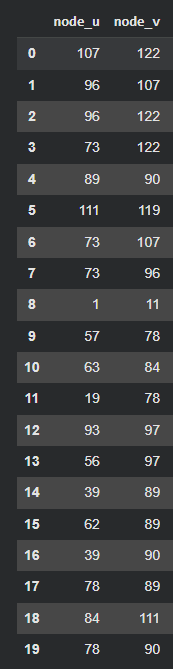

---
> 📤 **Submit to Canvas — Problem 2.3:** Submit your code and top 20 edge predictions.
---

## Problem 2.4
Generate a subgraph for nodes with eigenvector centrality higher than 0.1. Plot the network and upload the network graph.
Expected output:
- code
- gragh

> 💡 **Hint:** See class notebook **Section 1.6** for filtering nodes by a threshold attribute value and generating a subgraph.

Nodes in subgraph: 34


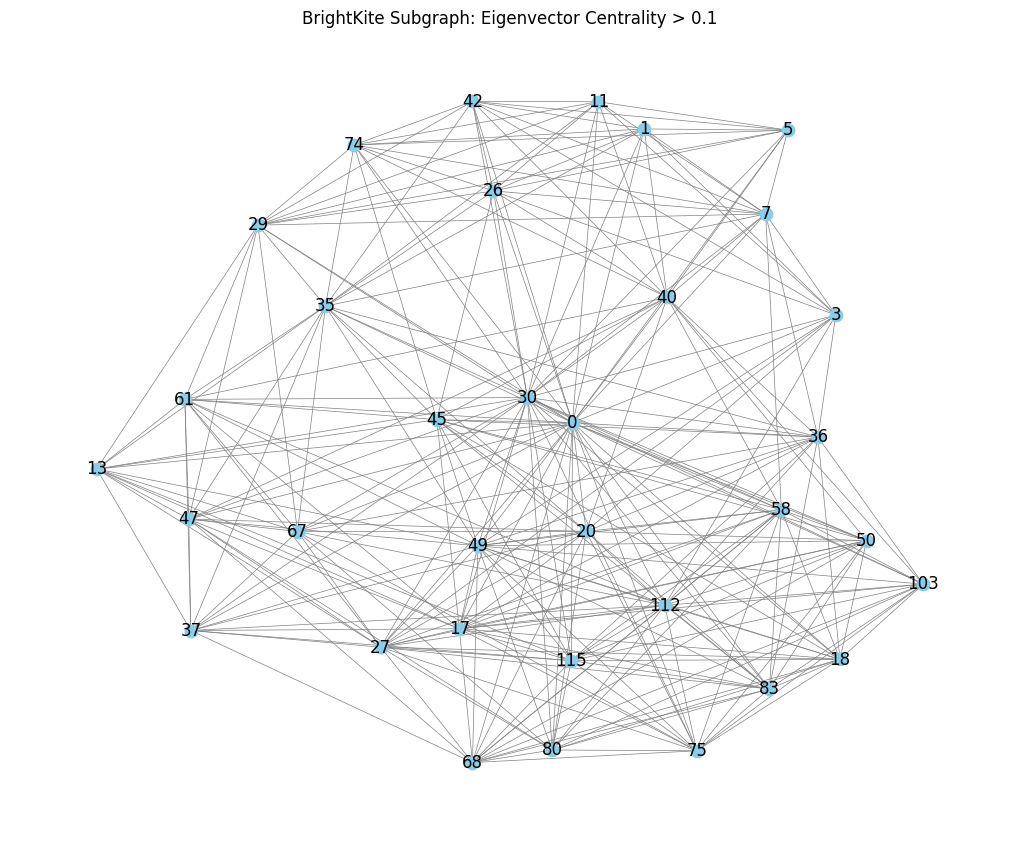

In [ ]:
selected_nodes = []
for node, data in G.nodes(data=True):
    if data.get('eigenvector_centrality', 0) > 0.1:
        selected_nodes.append(node)

subgraph = G.subgraph(selected_nodes).copy()

print(f"Nodes in subgraph: {subgraph.number_of_nodes()}")

plt.figure(figsize=(10, 8))
if subgraph.number_of_nodes() > 0:
    nx.draw(
        subgraph,
        with_labels=True,
        node_size=80,
        node_color='skyblue',
        width=0.5,
        edge_color='gray',
        pos=nx.kamada_kawai_layout(subgraph)
    )
    plt.title('BrightKite Subgraph: Eigenvector Centrality > 0.1')
else:
    plt.text(0.5, 0.5, 'No nodes met the threshold.', ha='center', va='center')
    plt.axis('off')
plt.show()

### Your Output — Problem 2.4

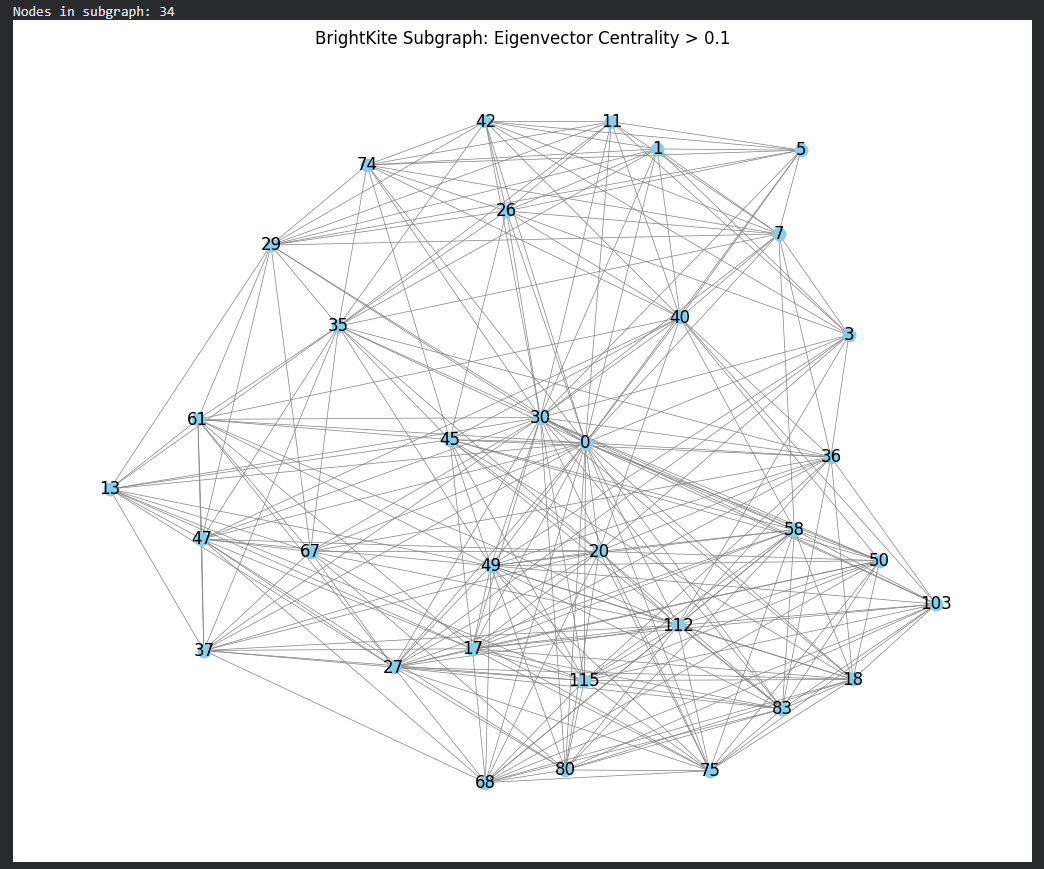

---
> 📤 **Submit to Canvas — Problem 2.4:** Upload the subgraph of nodes with eigenvector centrality > 0.1.
---

## Problem 2.5
Run a linear regression to explore how centrality measures affect the outcome of log(checkins+1).
Expected output:
- code
- regression results
- interpretation

> 💡 **Hint:** See class notebook **Section 1.7** for setting up node attributes as model inputs and running a linear regression.

In [ ]:
import numpy as np

df_model = attributes_df[
    ['eigenvector_centrality', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'checkins']
].copy()

df_model = df_model.dropna()
df_model['log_checkins'] = np.log1p(df_model['checkins'])

X = df_model[['eigenvector_centrality', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality']]
y = df_model['log_checkins']

try:
    import pingouin as pg
    result = pg.linear_regression(X, y)
    result[['names', 'coef', 'pval']] = result[['names', 'coef', 'pval']].round(4)
    r2_value = result['r2'].iloc[0]
except ImportError:
    import statsmodels.api as sm
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()
    result = pd.DataFrame({
        'names': model.params.index,
        'coef': model.params.values,
        'pval': model.pvalues.values
    }).round(4)
    r2_value = model.rsquared

print(f"R² = {r2_value:.4f}")
display(result[['names', 'coef', 'pval']])

significant_predictors = result.loc[
    (result['names'] != 'Intercept') & (result['pval'] < 0.05),
    'names'
].tolist()

if significant_predictors:
    print("Significant predictors (p < 0.05):", ", ".join(significant_predictors))
else:
    print("Significant predictors (p < 0.05): None")

print(
    "Interpretation: predictors with p < 0.05 are statistically significant. "
    "A positive coefficient means higher centrality is associated with more check-ins, "
    "while a negative coefficient means the opposite. The R² tells us how much of the "
    "variation in log(checkins + 1) is explained by the model."
)



R² = 0.3945


,names,coef,pval
0,const,196.4836,0.0035
1,eigenvector_centrality,19.6483,0.2073
2,degree_centrality,110.4850,0.0074
3,betweenness_centrality,131.3800,0.0063
4,closeness_centrality,-386.4788,0.0042


Significant predictors (p < 0.05): const, degree_centrality, betweenness_centrality, closeness_centrality
Interpretation: predictors with p < 0.05 are statistically significant. A positive coefficient means higher centrality is associated with more check-ins, while a negative coefficient means the opposite. The R² tells us how much of the variation in log(checkins + 1) is explained by the model.


### Your Output — Problem 2.5

```
+------------------------------------------------------------+
| Interpret the regression results here.                     |
| - Which centrality measures are significant predictors     |
|   of check-ins?                                            |
| - What does the R² tell you about the model?               |
|                                                            |
|                                                            |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.5:** Submit your  regression results and interpretation. (keep your code here)
---

# Problem 3

In our class exercise, we used function 'search_tweets_by_topic' from package itom6219 to retrieve tweets based on topic.
In this homework exercise, I designed a workflow to get you familiar with how to build a query to retrieve posts from X.
Take a moment to read this page: https://docs.x.com/x-api/posts/search/integrate/build-a-query


## Problem 3.1 Start with a basic query
- Create a query that includes the keyword of both "SMU" and "Football". Note that the AND operator is a space in X API.
- Set `include_mentions=False`
- `max_results=10`
- Save the output to `tweets_dict`

> 💡 **Hint:** See class notebook **Section 2.1** for the query syntax table and examples of combining keywords with Boolean operators.

In [6]:
import os
from itom6219 import user_info, user_tweets, user_tweets_all, search_tweets_by_topic, extract_user_mention_edges

try:
    from google.colab import userdata
    os.environ["BEARER_TOKEN"] = userdata.get('BEARER_TOKEN')
except Exception:
    pass

tweets_dict = search_tweets_by_topic(
    topic="SMU Football",  # AND is a space in the X API query syntax
    include_mentions=False,
    max_results=10
)

use `tweets_df = pd.DataFrame(tweets_dict['data'])` to turn the dictionary into a dataframe.

Use the code `pd.set_option('display.max_colwidth', None)` to allow full display of pandas content

In [7]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

,entities,text,author_id,id,public_metrics,created_at,edit_history_tweet_ids
0,"{'mentions': [{'start': 0, 'end': 12, 'username': 'clifferrell', 'id': '366746332'}, {'start': 13, 'end': 28, 'username': 'TheDeacMachine', 'id': '1260990015309582336'}]}",@clifferrell @TheDeacMachine Dickert seems pretty happy with the funding he’s getting. I like to see it get to about 20 million that’s what SMU spent when they went to the college football playoffs two years ago.,1805627954115805184,2040290069773189494,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 21}",2026-04-04T04:47:14.000Z,[2040290069773189494]
1,"{'mentions': [{'start': 92, 'end': 102, 'username': 'Thamannjr', 'id': '198999077'}]}","It was a pleasure to chat with and lock in with the Director of Player Personnel Coach Mann @Thamannjr !! From one of the top programs in the ACC, the team even shocked the college football world last year, Southern Methodist University Mustangs (SMU) 🐎💙❤️ !! \n\nGot to show him https://t.co/el0WBli7pK",1993005649496600576,2040267974934659352,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 2, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 89}",2026-04-04T03:19:26.000Z,[2040267974934659352]
2,"{'mentions': [{'start': 0, 'end': 15, 'username': 'kj7_enthusiast', 'id': '1985199006004207616'}, {'start': 16, 'end': 27, 'username': 'PeteThamel', 'id': '68441962'}]}",@kj7_enthusiast @PeteThamel Still in your head speaks a lot about SMU football,1863809062304980992,2040240646758261232,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 16}",2026-04-04T01:30:50.000Z,[2040240646758261232]
3,"{'mentions': [{'start': 4, 'end': 16, 'username': 'BillyEmbody', 'id': '67782321'}]}",Per @BillyEmbody \nIn-depth look at SMU spring football practice Friday ahead of the weekend off for the Mustangs.#RunWithUs https://t.co/B08xWe2GTb \nhttps://t.co/7lobc30GGf,1470881109915414531,2040238793408565578,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 1, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 42}",2026-04-04T01:23:28.000Z,[2040238793408565578]
4,NaN,In-depth look at SMU spring football practice Friday ahead of the weekend off for the Mustangs.\n\n#RunWithUs https://t.co/jY873kCm0X,67782321,2040234156832022601,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 15, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 2719}",2026-04-04T01:05:03.000Z,[2040234156832022601]
5,NaN,"Practice Report: SMU standouts of Week 2, new developments in spring football👀\n\nhttps://t.co/f9aICB8M1i https://t.co/uCDQ8oC1b0",2031803388082683904,2040234022819749918,"{'retweet_count': 2, 'reply_count': 1, 'like_count': 16, 'quote_count': 1, 'bookmark_count': 0, 'impression_count': 7003}",2026-04-04T01:04:31.000Z,[2040234022819749918]
6,"{'mentions': [{'start': 0, 'end': 11, 'username': 'PonyUpGang', 'id': '554044139'}, {'start': 12, 'end': 21, 'username': 'MGTXFROG', 'id': '1527127396557672449'}, {'start': 22, 'end': 33, 'username': 'ACCessPony', 'id': '1427640453466398738'}]}","@PonyUpGang @MGTXFROG @ACCessPony SMU edges it out for national renown. Latest US News rankings (2025-26): SMU #88, TCU #97. Forbes has SMU #103 vs TCU #120. SMU's Dallas location, stronger endowment per student, and business programs give it the broader prestige edge outside Texas. TCU's football peaks (like",1720665183188922368,2040232141070516407,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 45}",2026-04-04T00:57:02.000Z,[2040232141070516407]
7,NaN,"South Carolina landed the real deal in three-star QB Jerry Meyer III out of Waxahachie, Texas.\n\nThe 6A starting quarterback has thrown for 8,773 yards and 120 touchdowns, with one more season of high school football remaining. He chose the Gamecocks over Ole Miss, Arkansas, SMU, https://t.co/pPXr1OQYwr",121652356597518745

## Problem 3.3 Broaden for better coverage

Broaden coverage by using OR to include additional sports topics (e.g., `(SMU Football) OR (SMU Basketball)`).

> 💡 **Hint:** See class notebook **Section 2.1** for examples of using Boolean OR to combine multiple topic queries.

In [8]:
tweets_dict = search_tweets_by_topic(
    topic="(SMU Football) OR (TCU Football)",
    include_mentions=False,
    max_results=10
)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

,text,entities,created_at,public_metrics,edit_history_tweet_ids,author_id,id
0,"@rhettlashlee I love JC and SMU Football, coach.","{'mentions': [{'start': 0, 'end': 13, 'username': 'rhettlashlee', 'id': '157531194'}]}",2026-04-05T21:53:38.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 28}",[2040910763645157851],217801810,2040910763645157851
1,Seeing UL fans say shit like “yeah I think we got SMU this year” in football completely delegitimizes literally everything lol.,NaN,2026-04-05T17:14:58.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 18}",[2040840634043449708],245601274,2040840634043449708
2,"@UM_radio_Mic @AficionadoCFB That’s a stretch when Miami couldn’t beat a bad SMU &amp; Louisville team this year. That’s not how college football works. One thing you’re right about, it’ll mean 0 so let’s stop acting like a cotton bowl win was your Super Bowl &amp; actually win something. Goodnight https://t.co/7PJJ0QTKJw","{'mentions': [{'start': 0, 'end': 13, 'username': 'UM_radio_Mic', 'id': '178954308'}, {'start': 14, 'end': 28, 'username': 'AficionadoCFB', 'id': '1705408436211453952'}]}",2026-04-05T04:43:01.000Z,"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 15}",[2040651398698701202],1283215074723848192,2040651398698701202
3,@ironmikeluke First Cats let SMU football go up 22 in a bowl game. Now tonight.\n\nWhat is with our great teams looking their worst at the times they need to be great most?,"{'mentions': [{'start': 0, 'end': 13, 'username': 'ironmikeluke', 'id': '1072730654'}]}",2026-04-05T02:35:22.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 1, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 52}",[2040619272750223502],810350945888509952,2040619272750223502
4,Basketball pays for NDfull fsu clem miami \n\nInstead of losing money to stan cal smu \n\nThey contribute to b12 football https://t.co/g11otax0cf,NaN,2026-04-04T23:04:00.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 159}",[2040566080163164607],1427723126331351048,2040566080163164607
5,@dylanxciv @tominsalem @CasualHoya Duke football isn’t awful. Louisville is good. Smu is good. It would only work if football stayed decent. Or they wouldn’t come. Wake Forrest and NC state wouldn’t be excluded,"{'mentions': [{'start': 0, 'end': 10, 'username': 'dylanxciv', 'id': '1845648846212218882'}, {'start': 11, 'end': 22, 'username': 'tominsalem', 'id': '250094384'}, {'start': 23, 'end': 34, 'username': 'CasualHoya', 'id': '26624619'}]}",2026-04-04T18:08:37.000Z,"{'retweet_count': 0, 'reply_count': 2, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 25}",[2040491748091195884],540422308,2040491748091195884
6,Don't miss the inside scoop from SMU football practice with Run Peruna Run!\n\nJoin today and support NIL efforts for the Mustangs! #RunWithUs https://t.co/tQaE8akzQ2,NaN,2026-04-04T15:34:51.000Z,"{'retweet_count': 1, 'reply_count': 1, 'like_count': 9, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 146}",[2040453050859466817],2031803388082683904,2040453050859466817
7,"SMU DB Breakdown: 2025 Review, Spring Football Outlook https://t.co/ZsSsV0jIEy",NaN,2026-04-04T15:00:39.000Z,"{'retweet_count': 0, 'reply_count': 0, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 6}",[2040444441903911133],1695129127882211328,2040444441903911133
8,@clifferrell @TheDeacMachine Dickert seems pretty happy with the funding he’s getting. I like to see it get to about 20 million that’s what SMU spent when they went to the college football playoffs two years ago.,"{'mentions': [{'start': 0, 'end': 12, 'username': 'clifferrell', 'id': '366746332'}, {'start': 13, 'end': 28, 'username': 'TheDeacMachine', 'id': '1260990015309582336'}]

## Problem 3.4 Add emotion filters

Now add emotion keywords (e.g., `(happy OR happiness OR excited OR elated)`) to your query from 3.3. Use grouping with parentheses so that the query matches tweets about SMU sports AND containing an emotion keyword.

> 💡 **Hint:** See class notebook **Section 2.1** for examples of grouping with parentheses to combine topic and emotion filters in a single query.

In [13]:
tweets_dict = search_tweets_by_topic(
    topic="(SMU Football) (happy OR excited OR favorite) OR (TCU Football) (happy OR excited OR favorite)",
    include_mentions=False,
    max_results=10
)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

,text,entities,edit_history_tweet_ids,public_metrics,created_at,id,author_id
0,@clifferrell @TheDeacMachine Dickert seems pretty happy with the funding he’s getting. I like to see it get to about 20 million that’s what SMU spent when they went to the college football playoffs two years ago.,"{'mentions': [{'start': 0, 'end': 12, 'username': 'clifferrell', 'id': '366746332'}, {'start': 13, 'end': 28, 'username': 'TheDeacMachine', 'id': '1260990015309582336'}]}",[2040290069773189494],"{'retweet_count': 0, 'reply_count': 1, 'like_count': 0, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 21}",2026-04-04T04:47:14.000Z,2040290069773189494,1805627954115805184
1,"Excited to be attending @SMUFB camp this summer! Looking forward to learning from @rhettlashlee, @CoachRobLikens, and @bryanfilker and putting in the work 💪🔥 #SMU #Football #Grind https://t.co/eDacfD1IaO","{'mentions': [{'start': 24, 'end': 30, 'username': 'SMUFB', 'id': '312737543'}, {'start': 82, 'end': 95, 'username': 'rhettlashlee', 'id': '157531194'}, {'start': 97, 'end': 112, 'username': 'CoachRobLikens', 'id': '464848122'}, {'start': 118, 'end': 130, 'username': 'bryanfilker', 'id': '390209284'}]}",[2040161531241922965],"{'retweet_count': 1, 'reply_count': 0, 'like_count': 9, 'quote_count': 0, 'bookmark_count': 0, 'impression_count': 586}",2026-04-03T20:16:28.000Z,2040161531241922965,1445129431127834637


## Problem 3.5 Export tweets to CSV file (only the last file)

This question is a practice of the function `to_csv` which can export a pandas dataframe as a csv file. It will be listed in the file section of Google Colab for you to download and upload to Canvas.

In [14]:
tweets_df.to_csv("smu_vs_tcu_sports_emotion_tweets.csv", index=False)

> 📤 **Submit to Canvas — Problem 3.5:** Submit a csv file with your collected tweet(s).